# 🧠 Brain Tumor MRI Classification with Explainable Deep Learning

Self-contained, single-notebook version of the full pipeline (CNN baseline / ResNet50 / EfficientNet-B0, Grad-CAM, Saliency Maps) designed to run top-to-bottom on a **Kaggle GPU kernel** with zero external setup.

**Before running:** add/download the dataset from kaggle → search **"Brain Tumor MRI Dataset"** (`masoudnickparvar/brain-tumor-mri-dataset`)

Structure:
1. Setup & config
2. Dataset & dataloaders
3. Models (CNN / ResNet50 / EfficientNet-B0/ViT)
4. Training loop (config-driven, checkpointing, early stopping, LR scheduling)
5. Evaluation (metrics, confusion matrix, error analysis)
6. Explainability (Grad-CAM, Saliency Maps)
7. Benchmark comparison across all three models


## 1. Setup

In [16]:
# install torch/torchvision/sklearn/matplotlib/seaborn.
# Need to add grad-cam (pytorch-grad-cam) and captum for explainability.
#!pip install -q grad-cam captum


In [17]:
import os, json, random, copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
#from torchvision.models import resnet50, ResNet50_Weights, efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    vit_b_16, ViT_B_16_Weights,
)
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


Torch: 2.13.0 | CUDA available: False


### Configuration

In [18]:
# ---------------------------------------------------------------
# CONFIG — Local / macOS / Apple Silicon
# ---------------------------------------------------------------
import os
import random
from pathlib import Path

import numpy as np
import torch


# ---------------------------------------------------------------
# Device detection
# ---------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        return "cuda"

    if torch.backends.mps.is_available():
        return "mps"

    return "cpu"


DEVICE = get_device()


# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
CFG = {
    "seed": 42,
    "device": DEVICE,

    # -----------------------------------------------------------
    # Dataset
    # -----------------------------------------------------------
    # Change this to your local dataset directory.
    #
    # Example:
    # "/Users/shuvo/datasets/brain_tumor"
    #
    "data_root": "./data",

    "class_names": [],

    "image_size": 224,
    "batch_size": 32,

    # Mac can usually handle 0–4 workers depending on the dataset.
    # Start with 2 if you are unsure.
    "num_workers": 2,

    "train_split": 0.8,
    "val_split": 0.1,
    "test_split": 0.1,

    "normalize_mean": [
        0.485,
        0.456,
        0.406
    ],

    "normalize_std": [
        0.229,
        0.224,
        0.225
    ],

    # -----------------------------------------------------------
    # Model
    # -----------------------------------------------------------
    "architecture": "efficientnet_b0",
    # Options:
    # "cnn_baseline"
    # "resnet50"
    # "efficientnet_b0"

    "pretrained": True,
    "dropout": 0.3,

    # -----------------------------------------------------------
    # Training
    # -----------------------------------------------------------
    "epochs": 5, #for basic test used 5 epochs but in production prefer run #20,

    "learning_rate": 3e-4,
    "weight_decay": 1e-4,

    "label_smoothing": 0.05,

    "early_stopping_patience": 6,
    "early_stopping_min_delta": 0.001,

    "gradient_clip_norm": 1.0,

    # -----------------------------------------------------------
    # Mixed precision
    # -----------------------------------------------------------
    # CUDA: True
    # MPS: False initially for stability
    # CPU: False
    #
    # You can later experiment with True on MPS.
    "mixed_precision": (
        DEVICE == "cuda"
    ),

    # -----------------------------------------------------------
    # Local output directories
    # -----------------------------------------------------------
    "checkpoint_dir": "./checkpoints",
    "results_dir": "./results",
}


# ---------------------------------------------------------------
# Create directories
# ---------------------------------------------------------------
Path(CFG["checkpoint_dir"]).mkdir(
    parents=True,
    exist_ok=True
)

Path(CFG["results_dir"]).mkdir(
    parents=True,
    exist_ok=True
)

Path(CFG["results_dir"], "figures").mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------
def set_seed(seed=42):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    # Only call CUDA-specific functions when CUDA exists
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(CFG["seed"])


# ---------------------------------------------------------------
# Print configuration
# ---------------------------------------------------------------
print("=" * 60)
print("Training Configuration")
print("=" * 60)

print(f"Device       : {CFG['device']}")
print(f"Architecture : {CFG['architecture']}")
print(f"Dataset      : {CFG['data_root']}")
print(f"Batch size   : {CFG['batch_size']}")
print(f"Epochs       : {CFG['epochs']}")
print(f"Mixed prec.  : {CFG['mixed_precision']}")

print("=" * 60)

Training Configuration
Device       : mps
Architecture : efficientnet_b0
Dataset      : ./data
Batch size   : 32
Epochs       : 5
Mixed prec.  : False


In [19]:
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

True
True


In [20]:
# ---------------------------------------------------------------
# AUTO-DETECT DATASET PATH — LOCAL / macOS
# ---------------------------------------------------------------
from pathlib import Path
import os


# ---------------------------------------------------------------
# Local dataset search locations
# ---------------------------------------------------------------
search_roots = [
    Path("./data"),
    Path("./datasets"),
    Path("./dataset"),
    Path.home() / "Datasets",
    Path.home() / "datasets",
]


print("Searching for brain tumor MRI dataset...")
print()


# ---------------------------------------------------------------
# Find directories containing Training/
# ---------------------------------------------------------------
candidates = []

for root in search_roots:

    if not root.exists():
        continue

    # Search up to a few levels deep
    for p in root.rglob("*"):

        if not p.is_dir():
            continue

        # Standard layout:
        # dataset/
        # ├── Training/
        # └── Testing/
        if (p / "Training").is_dir():
            candidates.append(p)


# ---------------------------------------------------------------
# Select dataset
# ---------------------------------------------------------------
data_root = None

if candidates:
    # Prefer paths containing "brain" and "tumor"
    preferred = [
        p for p in candidates
        if "brain" in p.name.lower()
        and "tumor" in p.name.lower()
    ]

    if preferred:
        data_root = preferred[0]
    else:
        data_root = candidates[0]


# ---------------------------------------------------------------
# Validate
# ---------------------------------------------------------------
if data_root is None:

    print("Could not automatically find the dataset.")
    print()
    print("Expected structure:")
    print("""
    data/
    └── Brain Tumor MRI Dataset/
        ├── Training/
        │   ├── glioma/
        │   ├── meningioma/
        │   ├── notumor/
        │   └── pituitary/
        └── Testing/
            ├── glioma/
            ├── meningioma/
            ├── notumor/
            └── pituitary/
    """)

    raise FileNotFoundError(
        "Dataset not found. Set CFG['data_root'] manually."
    )


# ---------------------------------------------------------------
# Handle extra nesting
# ---------------------------------------------------------------
if not (data_root / "Training").exists():

    nested = [
        p for p in data_root.iterdir()
        if p.is_dir() and (p / "Training").is_dir()
    ]

    if nested:
        data_root = nested[0]


# ---------------------------------------------------------------
# Update configuration
# ---------------------------------------------------------------
CFG["data_root"] = str(data_root)


# ---------------------------------------------------------------
# Print detected dataset
# ---------------------------------------------------------------
print("=" * 60)
print("Dataset detected")
print("=" * 60)

print("Using data_root:", CFG["data_root"])

training_dir = data_root / "Training"
testing_dir = data_root / "Testing"

class_names = []

print("\nTraining classes:")

if training_dir.exists():
    for p in sorted(training_dir.iterdir()):
        if p.is_dir():
            count = len([
                f for f in p.iterdir()
                if f.is_file()
            ])
            print(f" - {p.name}: {count} images")
            class_names.append(p.name)

print("\nTesting classes:")

if testing_dir.exists():
    for p in sorted(testing_dir.iterdir()):
        if p.is_dir():
            count = len([
                f for f in p.iterdir()
                if f.is_file()
            ])
            print(f" - {p.name}: {count} images")

print("=" * 60)

print("Extracted class_names:", class_names)
# ===============================================================
# UPDATE CFG
# =============================================================== 
CFG["class_names"] = class_names

Searching for brain tumor MRI dataset...

Dataset detected
Using data_root: data/Brain Tumor MRI Dataset

Training classes:
 - glioma: 1400 images
 - meningioma: 1400 images
 - notumor: 1400 images
 - pituitary: 1400 images

Testing classes:
 - glioma: 400 images
 - meningioma: 400 images
 - notumor: 400 images
 - pituitary: 400 images
Extracted class_names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [21]:
print(CFG["class_names"])

['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Dataset & Dataloaders

In [22]:
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split


class BrainTumorMRIDataset(Dataset):
    """Loads MRI images + labels from a class-per-folder layout."""

    def __init__(self, samples, class_names, transform=None):
        self.samples = samples
        self.class_names = class_names
        self.transform = transform

    @classmethod
    def from_folder(cls, root, class_names):
        root = Path(root)

        valid_ext = {
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        }

        samples = []

        for label_idx, class_name in enumerate(class_names):

            class_dir = root / class_name

            if not class_dir.exists():
                print(f"Warning: missing class directory: {class_dir}")
                continue

            for img_path in sorted(class_dir.iterdir()):

                if (
                    img_path.is_file()
                    and img_path.suffix.lower() in valid_ext
                ):
                    samples.append(
                        (str(img_path), label_idx)
                    )

        return cls(
            samples,
            class_names
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(
                f"Could not read image: {img_path}"
            ) from e

        if self.transform is not None:
            image = self.transform(image)

        return image, label, img_path


# ---------------------------------------------------------------
# Collect dataset samples
# ---------------------------------------------------------------
def collect_all_samples(cfg):

    root = Path(cfg["data_root"])
    class_names = cfg["class_names"]

    samples = []

    # Standard dataset structure:
    #
    # data_root/
    # ├── Training/
    # └── Testing/
    #
    for sub in ["Training", "Testing"]:

        subdir = root / sub

        if subdir.exists():

            dataset = BrainTumorMRIDataset.from_folder(
                subdir,
                class_names
            )

            samples.extend(dataset.samples)

    # Fallback:
    #
    # data_root/
    # ├── glioma/
    # ├── meningioma/
    # ├── notumor/
    # └── pituitary/
    #
    if not samples:

        samples = BrainTumorMRIDataset.from_folder(
            root,
            class_names
        ).samples

    if not samples:
        raise RuntimeError(
            f"No images found under {root}"
        )

    return samples


# ---------------------------------------------------------------
# Transforms
# ---------------------------------------------------------------
def build_transforms(cfg):

    size = cfg["image_size"]
    mean = cfg["normalize_mean"]
    std = cfg["normalize_std"]

    train_tf = transforms.Compose([
        transforms.Resize((size, size)),

        transforms.RandomHorizontalFlip(
            p=0.5
        ),

        transforms.RandomRotation(
            degrees=15
        ),

        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=mean,
            std=std
        ),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize((size, size)),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=mean,
            std=std
        ),
    ])

    return train_tf, eval_tf


# ---------------------------------------------------------------
# DataLoaders
# ---------------------------------------------------------------
def build_dataloaders(cfg):

    class_names = cfg["class_names"]

    samples = collect_all_samples(cfg)

    paths = [s[0] for s in samples]
    labels = [s[1] for s in samples]

    # -----------------------------------------------------------
    # 80% Train
    # 20% Temporary
    # -----------------------------------------------------------
    train_paths, temp_paths, train_labels, temp_labels = (
        train_test_split(
            paths,
            labels,
            train_size=cfg["train_split"],
            stratify=labels,
            random_state=cfg["seed"]
        )
    )

    # -----------------------------------------------------------
    # Split remaining 20% into:
    # 10% Validation
    # 10% Test
    # -----------------------------------------------------------
    rel_val = (
        cfg["val_split"]
        / (cfg["val_split"] + cfg["test_split"])
    )

    val_paths, test_paths, val_labels, test_labels = (
        train_test_split(
            temp_paths,
            temp_labels,
            train_size=rel_val,
            stratify=temp_labels,
            random_state=cfg["seed"]
        )
    )

    # -----------------------------------------------------------
    # Transforms
    # -----------------------------------------------------------
    train_tf, eval_tf = build_transforms(cfg)

    train_ds = BrainTumorMRIDataset(
        list(zip(train_paths, train_labels)),
        class_names,
        train_tf
    )

    val_ds = BrainTumorMRIDataset(
        list(zip(val_paths, val_labels)),
        class_names,
        eval_tf
    )

    test_ds = BrainTumorMRIDataset(
        list(zip(test_paths, test_labels)),
        class_names,
        eval_tf
    )

    print(
        f"Train: {len(train_ds)} | "
        f"Val: {len(val_ds)} | "
        f"Test: {len(test_ds)}"
    )

    # -----------------------------------------------------------
    # MPS / CUDA / CPU compatible DataLoader
    # -----------------------------------------------------------
    device = cfg["device"]

    # pin_memory is mainly useful for CUDA.
    # It is not necessary for MPS.
    pin_memory = device == "cuda"

    common = {
        "batch_size": cfg["batch_size"],
        "num_workers": cfg["num_workers"],
        # "pin_memory": pin_memory,
        "pin_memory": False
    }

    # -----------------------------------------------------------
    # macOS multiprocessing safety
    # -----------------------------------------------------------
    #
    # If DataLoader multiprocessing causes issues on macOS,
    # change CFG["num_workers"] to 0.
    #
    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        drop_last=True,
        **common
    )

    val_loader = DataLoader(
        val_ds,
        shuffle=False,
        **common
    )

    test_loader = DataLoader(
        test_ds,
        shuffle=False,
        **common
    )

    return {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader,
    }


# ---------------------------------------------------------------
# Class weights
# ---------------------------------------------------------------
def compute_class_weights(cfg):

    samples = collect_all_samples(cfg)

    labels = [
        s[1]
        for s in samples
    ]

    counts = torch.zeros(
        len(cfg["class_names"]),
        dtype=torch.float32
    )

    for label in labels:
        counts[label] += 1

    weights = (
        counts.sum()
        / (
            len(cfg["class_names"])
            * counts.clamp(min=1)
        )
    )

    return weights


# ---------------------------------------------------------------
# Build everything
# ---------------------------------------------------------------
# loaders = build_dataloaders(CFG)
loaders = build_dataloaders({
    **CFG,
    "num_workers": 0,
})

class_weights = compute_class_weights(CFG)

print("\nClass weights:")

for class_name, weight in zip(
    CFG["class_names"],
    class_weights
):
    print(
        f"  {class_name:12s}: {weight.item():.4f}"
    )

Train: 5760 | Val: 720 | Test: 720

Class weights:
  glioma      : 1.0000
  meningioma  : 1.0000
  notumor     : 1.0000
  pituitary   : 1.0000


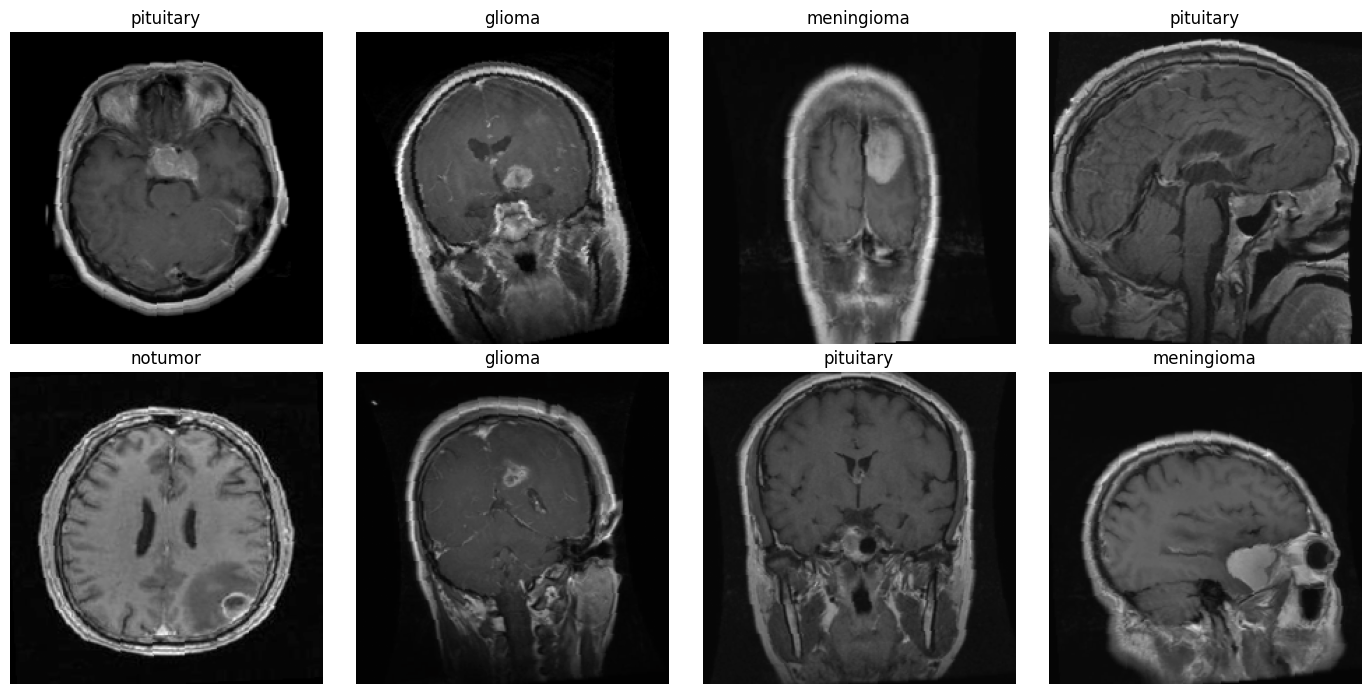

In [23]:
images, labels, paths = next(iter(loaders["train"]))

mean = torch.tensor(CFG["normalize_mean"]).view(3, 1, 1)
std = torch.tensor(CFG["normalize_std"]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    img = (
        images[i] * std + mean
    ).clamp(0, 1).permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(CFG["class_names"][labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Models

In [24]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
    def forward(self, x):
        return self.block(x)


class CNNBaseline(nn.Module):
    """4-block from-scratch CNN — establishes a lower bound vs. transfer learning."""
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.conv_block1 = ConvBlock(3, 32)
        self.conv_block2 = ConvBlock(32, 64)
        self.conv_block3 = ConvBlock(64, 128)
        self.conv_block4 = ConvBlock(128, 256)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(256, 128),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.conv_block1(x); x = self.conv_block2(x)
        x = self.conv_block3(x); x = self.conv_block4(x)
        return self.classifier(self.gap(x))
    @property
    def target_layer(self):
        return self.conv_block4
    is_transformer = False


class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=True, dropout=0.3):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.model = resnet50(weights=weights)
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))
    def forward(self, x):
        return self.model(x)
    @property
    def target_layer(self):
        return self.model.layer4[-1]
    is_transformer = False


class EfficientNetB0Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=True, dropout=0.3):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.model = efficientnet_b0(weights=weights)
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(nn.Dropout(dropout, inplace=True), nn.Linear(in_features, num_classes))
    def forward(self, x):
        return self.model(x)
    @property
    def target_layer(self):
        return self.model.features[-1]
    is_transformer = False


class ViTB16Classifier(nn.Module):
    """Vision Transformer (ViT-B/16) — bonus benchmark against the CNN family.

    Note the different Grad-CAM wiring vs. the CNN models above: a ViT has
    no spatial conv feature map, so Grad-CAM needs (a) a target layer that
    still carries a [batch, tokens, dim] activation — the last encoder
    block's first LayerNorm works well — and (b) a `reshape_transform` that
    converts the 197 tokens (1 CLS + 14x14 patches) back into a 14x14 grid
    before the CAM math runs. See `vit_reshape_transform` in the
    explainability cell below; `is_transformer=True` tells that cell to use it.
    """
    def __init__(self, num_classes, pretrained=True, dropout=0.1):
        super().__init__()
        weights = ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
        self.model = vit_b_16(weights=weights)
        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))
    def forward(self, x):
        return self.model(x)
    @property
    def target_layer(self):
        return self.model.encoder.layers[-1].ln_1
    is_transformer = True


def build_model(architecture, num_classes, pretrained=True, dropout=0.3):
    if architecture == "cnn_baseline":
        return CNNBaseline(num_classes=num_classes, dropout=dropout)
    if architecture == "resnet50":
        return ResNet50Classifier(num_classes=num_classes, pretrained=pretrained, dropout=dropout)
    if architecture == "efficientnet_b0":
        return EfficientNetB0Classifier(num_classes=num_classes, pretrained=pretrained, dropout=dropout)
    if architecture == "vit_b16":
        return ViTB16Classifier(num_classes=num_classes, pretrained=pretrained, dropout=dropout)
    raise ValueError(f"Unknown architecture: {architecture}")


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


## 4. Metrics

In [25]:
def compute_metrics(y_true, y_pred, y_probs, class_names):
    num_classes = len(class_names)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics["roc_auc"] = (roc_auc_score(y_true, y_probs[:, 1]) if num_classes == 2
                               else roc_auc_score(y_true, y_probs, multi_class="ovr", average="macro"))
    except ValueError:
        metrics["roc_auc"] = float("nan")
    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred, labels=list(range(num_classes))).tolist()
    return metrics


## 5. Training Loop
Config-driven trainer with AdamW, cosine LR schedule, mixed precision, gradient clipping, early stopping (monitoring val F1), and checkpointing to `./checkpoints`.

In [26]:
class EarlyStopping:
    def __init__(self, patience=6, min_delta=0.001, mode="max"):
        self.patience, self.min_delta, self.mode = patience, min_delta, mode
        self.best_score, self.counter, self.should_stop = None, 0, False

    def _is_improvement(self, score):
        if self.best_score is None:
            return True
        return score > self.best_score + self.min_delta if self.mode == "max" else score < self.best_score - self.min_delta

    def step(self, score):
        if self._is_improvement(score):
            self.best_score = score; self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def run_epoch(model, loader, criterion, optimizer, scaler, device, cfg, train=True):
    model.train(train)
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for images, labels, _ in tqdm(loader, desc="train" if train else "val", leave=False):
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad(set_to_none=True)

            #with torch.cuda.amp.autocast(enabled=cfg["mixed_precision"]):
            with torch.amp.autocast('cuda', enabled=cfg["mixed_precision"]):
                logits = model(images)
                loss = criterion(logits, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg["gradient_clip_norm"])
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.detach().cpu())
            all_preds.append(probs.argmax(dim=1).detach().cpu())
            all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    preds = torch.cat(all_preds).numpy()
    labels_np = torch.cat(all_labels).numpy()
    probs_np = torch.cat(all_probs).numpy()
    metrics = compute_metrics(labels_np, preds, probs_np, CFG["class_names"])
    metrics["loss"] = avg_loss
    return metrics


def train_model(cfg):
    device = torch.device(cfg["device"])
    model = build_model(cfg["architecture"], len(cfg["class_names"]), cfg["pretrained"], cfg["dropout"]).to(device)
    total, trainable = count_params(model)
    print(f"[{cfg['architecture']}] params total={total:,} trainable={trainable:,}")

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=cfg["label_smoothing"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
    #scaler = torch.cuda.amp.GradScaler(enabled=cfg["mixed_precision"])
    scaler = torch.amp.GradScaler('cuda', enabled=cfg["mixed_precision"])
    early_stopper = EarlyStopping(patience=cfg["early_stopping_patience"], min_delta=cfg["early_stopping_min_delta"])

    ckpt_path = Path(cfg["checkpoint_dir"]) / f"{cfg['architecture']}_best.pth"
    history = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1": []}

    for epoch in range(1, cfg["epochs"] + 1):
        train_m = run_epoch(model, loaders["train"], criterion, optimizer, scaler, device, cfg, train=True)
        val_m = run_epoch(model, loaders["val"], criterion, optimizer, scaler, device, cfg, train=False)
        scheduler.step()

        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:03d} | train_loss={train_m['loss']:.4f} | val_loss={val_m['loss']:.4f} "
              f"| val_acc={val_m['accuracy']:.4f} | val_f1={val_m['f1_macro']:.4f} | lr={lr:.2e}")

        history["train_loss"].append(train_m["loss"])
        history["val_loss"].append(val_m["loss"])
        history["val_accuracy"].append(val_m["accuracy"])
        history["val_f1"].append(val_m["f1_macro"])

        if early_stopper.step(val_m["f1_macro"]):
            torch.save({"model_state_dict": model.state_dict(), "architecture": cfg["architecture"],
                        "epoch": epoch, "metrics": {k: v for k, v in val_m.items() if isinstance(v, (int, float))}},
                       ckpt_path)
            print(f"  -> saved new best checkpoint (val_f1={val_m['f1_macro']:.4f})")

        if early_stopper.should_stop:
            print(f"Early stopping at epoch {epoch}.")
            break

    with open(Path(cfg["results_dir"]) / f"{cfg['architecture']}_history.json", "w") as f:
        json.dump(history, f, indent=2)

    return model, history, ckpt_path


In [27]:
# Train the model set in CFG['architecture']. Re-run this cell (after changing
# CFG['architecture']) for each of: 'cnn_baseline', 'resnet50', 'efficientnet_b0'.
model, history, best_ckpt_path = train_model(CFG)
print("Best checkpoint:", best_ckpt_path)


[efficientnet_b0] params total=4,012,672 trainable=4,012,672


train:   0%|          | 0/180 [00:00<?, ?it/s]

val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 001 | train_loss=0.4723 | val_loss=0.3640 | val_acc=0.9403 | val_f1=0.9412 | lr=2.71e-04
  -> saved new best checkpoint (val_f1=0.9412)


train:   0%|          | 0/180 [00:00<?, ?it/s]

...

val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 004 | train_loss=0.2342 | val_loss=0.2473 | val_acc=0.9847 | val_f1=0.9847 | lr=2.86e-05
  -> saved new best checkpoint (val_f1=0.9847)


train:   0%|          | 0/180 [00:00<?, ?it/s]

val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 005 | train_loss=0.2311 | val_loss=0.2419 | val_acc=0.9847 | val_f1=0.9847 | lr=0.00e+00
Best checkpoint: checkpoints/efficientnet_b0_best.pth


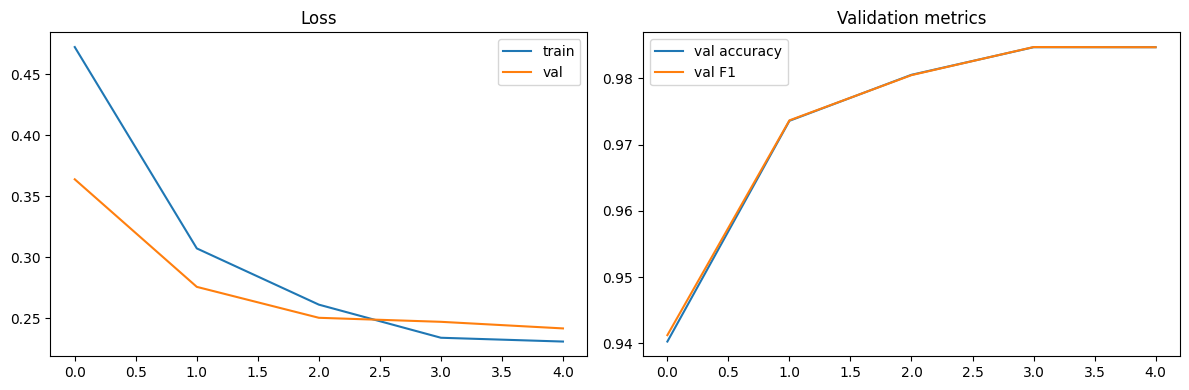

In [28]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["val_accuracy"], label="val accuracy")
axes[1].plot(history["val_f1"], label="val F1")
axes[1].set_title("Validation metrics"); axes[1].legend()
plt.tight_layout(); plt.show()


## 6. Evaluation on the Held-Out Test Set

In [29]:
@torch.no_grad()
def run_inference(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs, all_paths = [], [], [], []
    for images, labels, paths in loader:
        images = images.to(device)
        probs = torch.softmax(model(images), dim=1)
        all_probs.append(probs.cpu()); all_preds.append(probs.argmax(dim=1).cpu())
        all_labels.append(labels); all_paths.extend(paths)
    return (torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy(),
            torch.cat(all_probs).numpy(), all_paths)


def load_checkpoint(architecture, ckpt_path, device):
    m = build_model(architecture, len(CFG["class_names"]), pretrained=False, dropout=CFG["dropout"]).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    m.load_state_dict(ckpt["model_state_dict"])
    return m


device = torch.device(CFG["device"])
eval_model = load_checkpoint(CFG["architecture"], best_ckpt_path, device)
y_true, y_pred, y_probs, paths = run_inference(eval_model, loaders["test"], device)

metrics = compute_metrics(y_true, y_pred, y_probs, CFG["class_names"])
print(f"Test Accuracy:  {metrics['accuracy']:.4f}")
print(f"Test F1 (macro): {metrics['f1_macro']:.4f}")
print(f"Test ROC-AUC:    {metrics['roc_auc']:.4f}")

with open(Path(CFG["results_dir"]) / f"{CFG['architecture']}_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)


Test Accuracy:  0.9944
Test F1 (macro): 0.9944
Test ROC-AUC:    0.9985


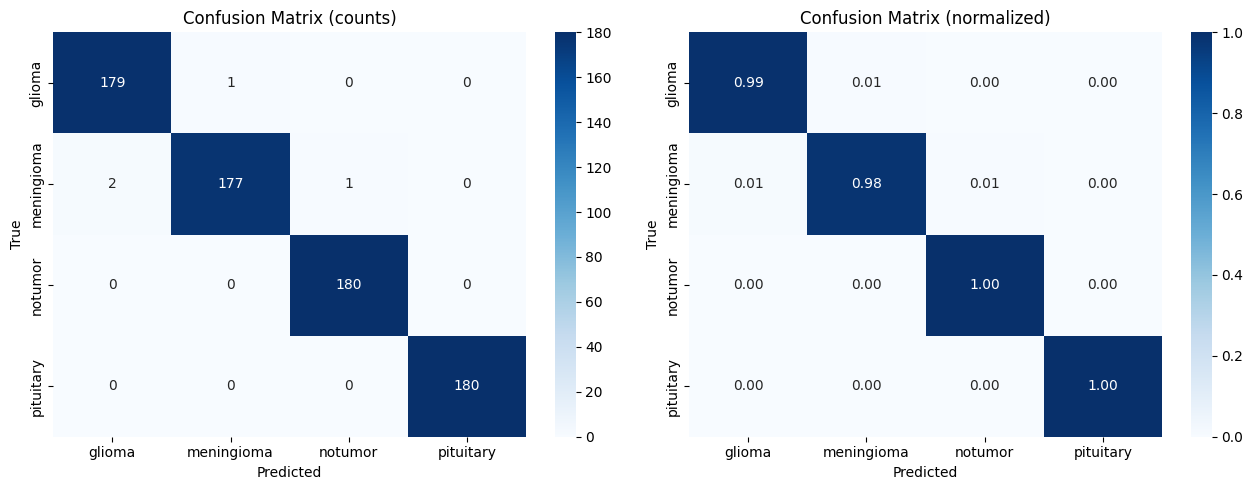

In [30]:
# Confusion matrix (counts + row-normalized)
cm = np.array(metrics["confusion_matrix"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CFG["class_names"], yticklabels=CFG["class_names"], ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CFG["class_names"], yticklabels=CFG["class_names"], ax=axes[1])
axes[1].set_title("Confusion Matrix (normalized)"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(Path(CFG["results_dir"]) / "figures" / f"{CFG['architecture']}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [31]:
# Error analysis: most confidently WRONG predictions
def collect_misclassified(y_true, y_pred, y_probs, paths, class_names, max_examples=20):
    wrong_idx = np.where(y_true != y_pred)[0]
    records = []
    for idx in wrong_idx:
        conf = float(y_probs[idx, y_pred[idx]])
        records.append({
            "image_path": paths[idx],
            "true_label": class_names[y_true[idx]],
            "predicted_label": class_names[y_pred[idx]],
            "confidence": conf,
        })
    records.sort(key=lambda r: r["confidence"], reverse=True)
    return records[:max_examples]

misclassified = collect_misclassified(y_true, y_pred, y_probs, paths, CFG["class_names"])
pd.DataFrame(misclassified).head(10)


,image_path,true_label,predicted_label,confidence
0,data/Brain Tumor MRI Dataset/Testing/glioma/Te...,glioma,meningioma,0.974251
1,data/Brain Tumor MRI Dataset/Training/meningio...,meningioma,notumor,0.844281
2,data/Brain Tumor MRI Dataset/Testing/meningiom...,meningioma,glioma,0.737287
3,data/Brain Tumor MRI Dataset/Training/meningio...,meningioma,glioma,0.720490


## 7. Explainability — Grad-CAM & Saliency Maps

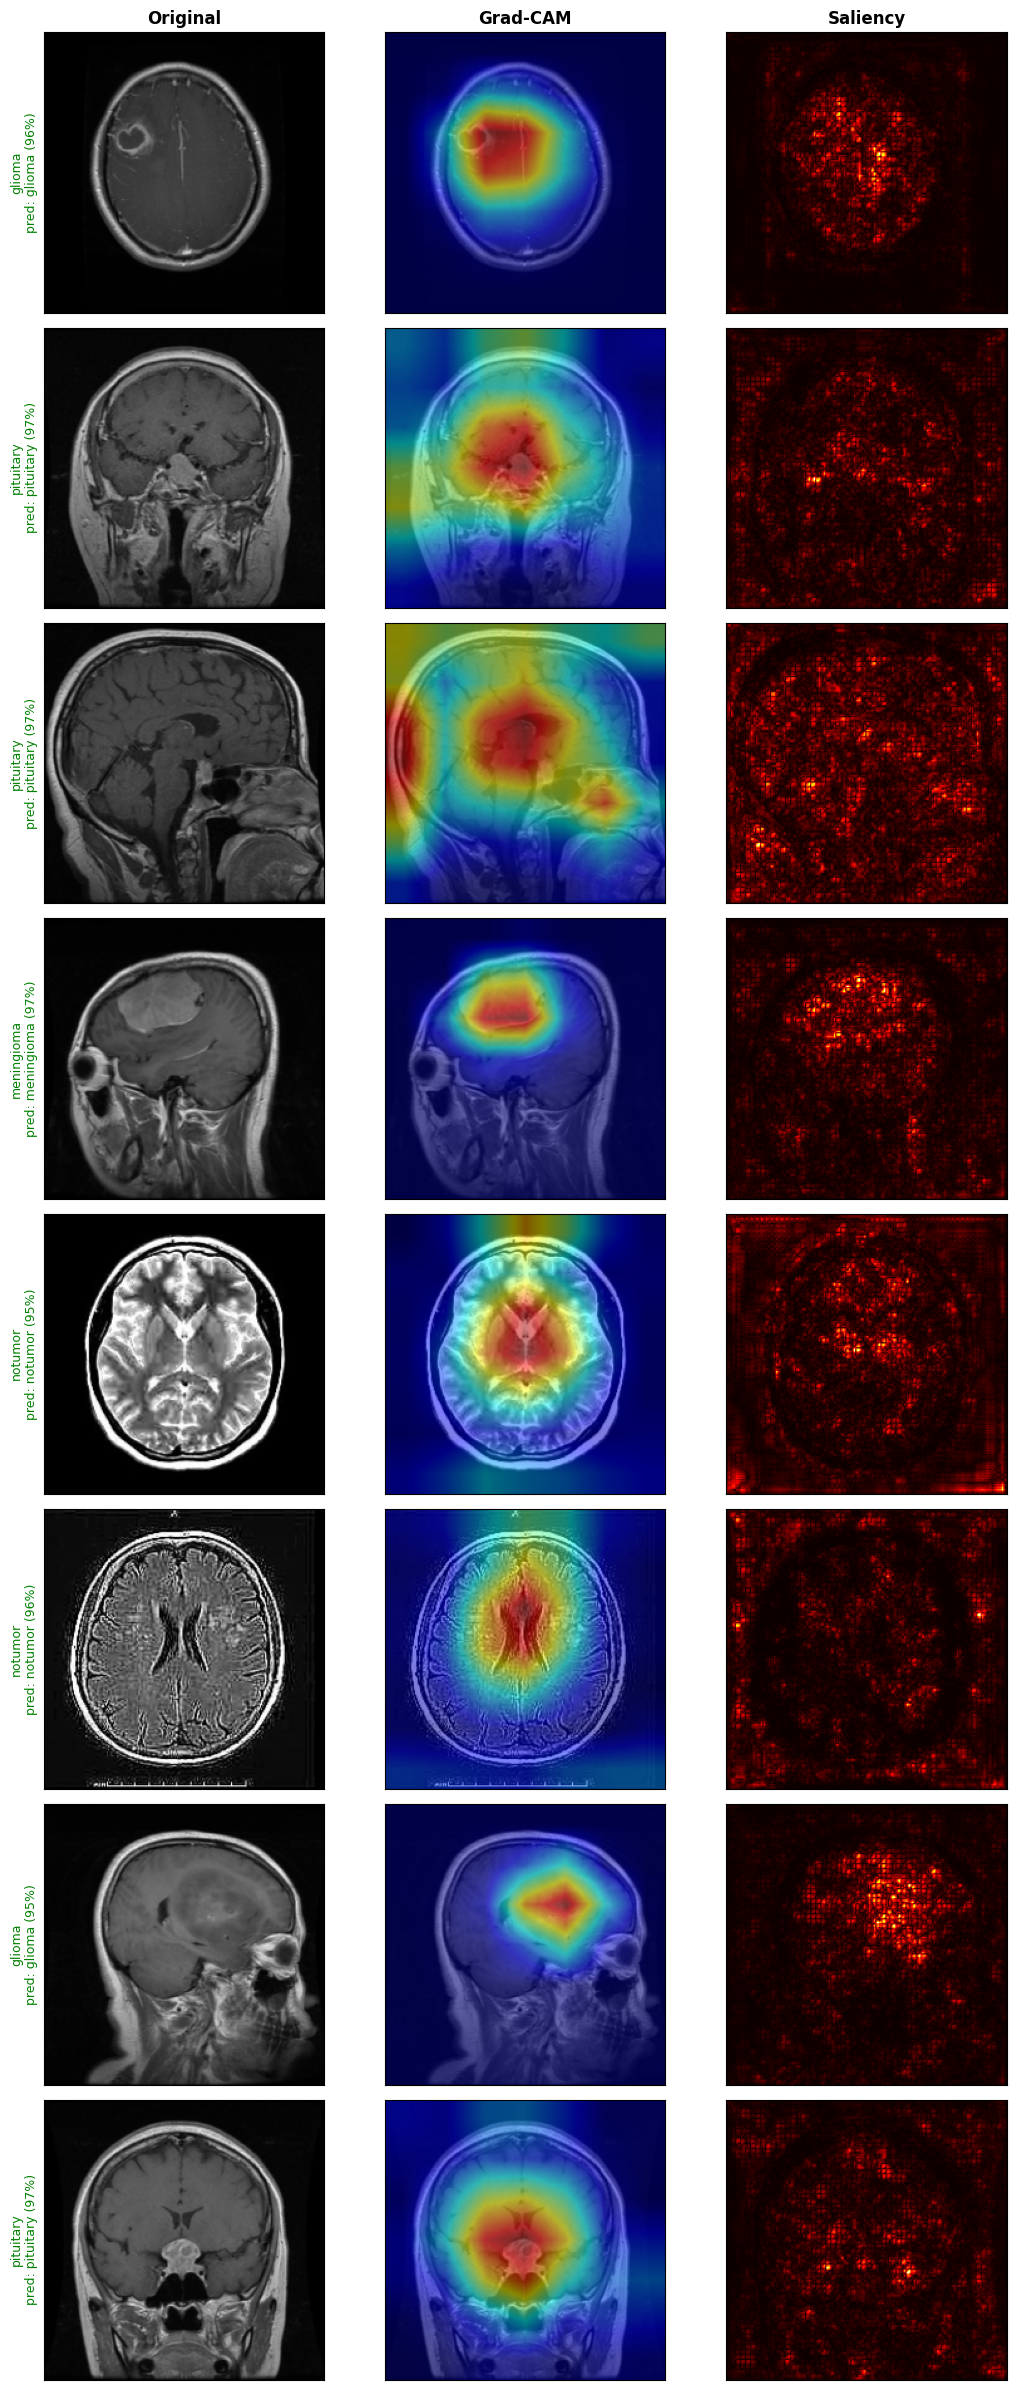

Saved -> results/figures/efficientnet_b0_explainability_dashboard.png


In [32]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from captum.attr import Saliency

mean_t = torch.tensor(CFG["normalize_mean"]).view(3, 1, 1)
std_t = torch.tensor(CFG["normalize_std"]).view(3, 1, 1)

def denormalize(tensor_img):
    return (tensor_img.cpu() * std_t + mean_t).clamp(0, 1)


def vit_reshape_transform(tensor, height=14, width=14):
    """Converts ViT token activations [batch, 1+H*W, dim] (CLS token + patch
    tokens) into a [batch, dim, H, W] spatial map so pytorch-grad-cam's CAM
    math (built for conv feature maps) works on a transformer. 14x14 matches
    ViT-B/16 at 224x224 input (224/16 = 14 patches per side)."""
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)  # -> [batch, dim, H, W]
    return result


def explain_and_plot(model, loader, device, num_samples=8):
    target_layer = model.target_layer
    is_transformer = getattr(model, "is_transformer", False)

    cam_kwargs = {"model": model, "target_layers": [target_layer]}
    if is_transformer:
        cam_kwargs["reshape_transform"] = vit_reshape_transform
    cam = GradCAM(**cam_kwargs)
    saliency = Saliency(model)

    images, labels, paths = next(iter(loader))
    images, labels = images[:num_samples].to(device), labels[:num_samples]

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(images), dim=1)
        preds = probs.argmax(dim=1)

    fig, axes = plt.subplots(num_samples, 3, figsize=(11, 3.0 * num_samples))
    for ax, title in zip(axes[0], ["Original", "Grad-CAM", "Saliency"]):
        ax.set_title(title, fontsize=12, fontweight="bold")

    for i in range(num_samples):
        img_tensor = images[i:i+1]
        rgb_img = denormalize(images[i]).permute(1, 2, 0).numpy().astype(np.float32)

        grayscale_cam = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(preds[i].item())])[0]
        cam_overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        sal_input = img_tensor.clone().requires_grad_(True)
        attribution = saliency.attribute(sal_input, target=preds[i].item())
        sal_map = attribution.squeeze(0).abs().max(dim=0)[0].detach().cpu().numpy()
        sal_map = (sal_map - sal_map.min()) / (sal_map.max() - sal_map.min() + 1e-8)

        true_name = CFG["class_names"][labels[i].item()]
        pred_name = CFG["class_names"][preds[i].item()]
        conf = probs[i, preds[i]].item()
        color = "green" if true_name == pred_name else "red"

        axes[i, 0].imshow(rgb_img)
        axes[i, 0].set_ylabel(f"{true_name}\npred: {pred_name} ({conf:.0%})", color=color, fontsize=9)
        axes[i, 1].imshow(cam_overlay)
        axes[i, 2].imshow(sal_map, cmap="hot")
        for j in range(3):
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])

    plt.tight_layout()
    out_path = Path(CFG["results_dir"]) / "figures" / f"{CFG['architecture']}_explainability_dashboard.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ->", out_path)


explain_and_plot(eval_model, loaders["test"], device, num_samples=8)


## 8. Benchmark Comparison Across Models

Re-run cells 5-6 with `CFG['architecture']` set to each of `'cnn_baseline'`, `'resnet50'`, `'efficientnet_b0'` (this saves a `{arch}_test_metrics.json` each time), then run this cell to build the comparison table.

In [33]:
rows = []
for arch in ["cnn_baseline", "resnet50", "efficientnet_b0", "vit_b16"]:
    path = Path(CFG["results_dir"]) / f"{arch}_test_metrics.json"
    if not path.exists():
        print(f"[skip] {arch}: not yet evaluated")
        continue
    with open(path) as f:
        m = json.load(f)
    rows.append({
        "Model": arch,
        "Accuracy": round(m["accuracy"], 4),
        "Precision (macro)": round(m["precision_macro"], 4),
        "Recall (macro)": round(m["recall_macro"], 4),
        "F1 (macro)": round(m["f1_macro"], 4),
        "ROC-AUC": round(m["roc_auc"], 4),
    })

if rows:
    df = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False)
    df.to_csv(Path(CFG["results_dir"]) / "benchmark_comparison.csv", index=False)
    display(df)
else:
    print("No models evaluated yet — run the training + evaluation cells for each architecture first.")


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC
2,efficientnet_b0,0.9944,0.9945,0.9944,0.9944,0.9985
1,resnet50,0.9903,0.9903,0.9903,0.9903,0.9998
0,cnn_baseline,0.8750,0.8821,0.8750,0.8750,0.9759
3,vit_b16,0.8736,0.8784,0.8736,0.8731,0.9752
